Primeros datos de la serie:
2020-01-31   -1.085631
2020-02-29   -0.196848
2020-03-31    0.989231
2020-04-30   -0.712212
2020-05-31   -2.055844
Freq: ME, dtype: float64


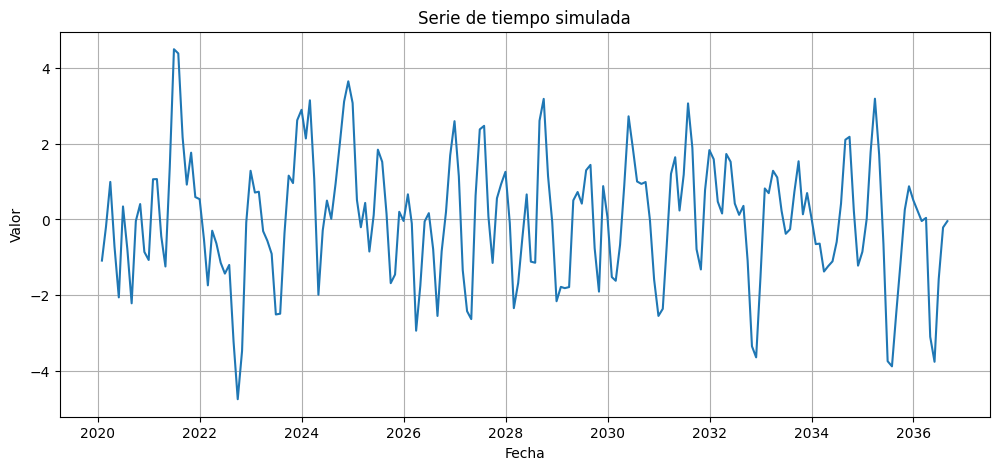

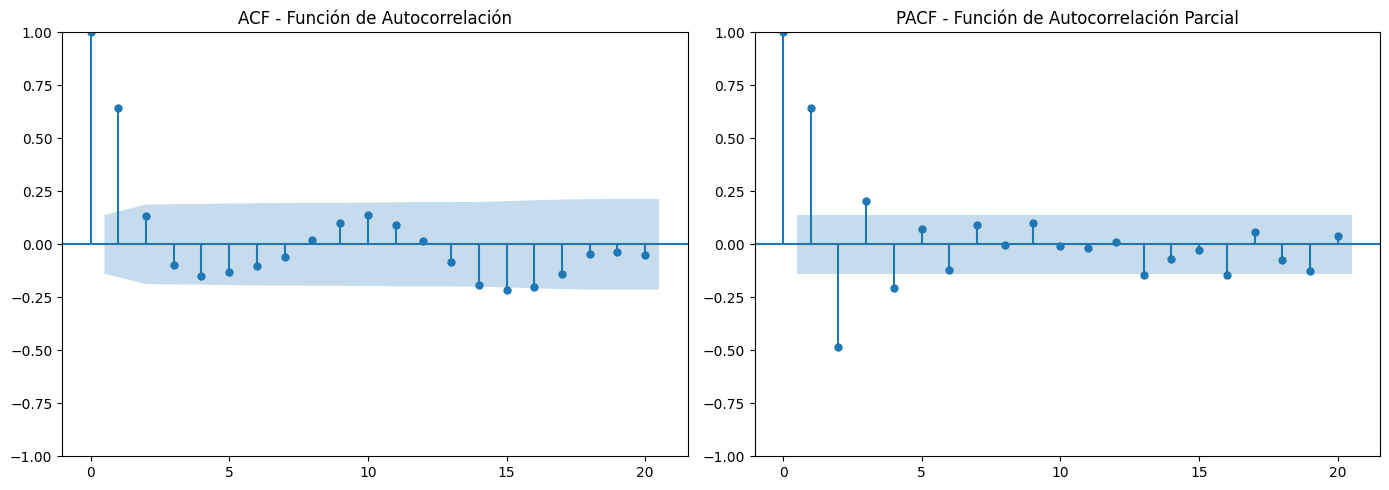

Top 10 modelos según AIC:
   p  d  q         AIC         BIC
0  3  0  2  592.224623  615.312844
1  1  0  3  593.269137  613.059042
2  3  0  3  593.363692  619.750231
3  0  0  2  595.118136  608.311406
4  2  0  1  595.147518  611.639104
5  2  0  2  595.414408  615.204312
6  0  0  3  595.922088  612.413675
7  3  0  1  596.082146  615.872050
8  1  0  1  596.209139  609.402409
9  1  0  2  596.284747  612.776334

Top 10 modelos según BIC:
   p  d  q         AIC         BIC
0  0  0  2  595.118136  608.311406
1  1  0  1  596.209139  609.402409
2  0  1  3  596.698990  609.872209
3  1  1  2  597.536070  610.709289
4  2  0  1  595.147518  611.639104
5  0  0  3  595.922088  612.413675
6  1  0  2  596.284747  612.776334
7  1  0  3  593.269137  613.059042
8  2  1  2  596.727186  613.193710
9  1  1  3  597.723260  614.189784

Mejor modelo según AIC:
ARIMA(3,0,2) con AIC = 592.22

Mejor modelo según BIC:
ARIMA(0,0,2) con BIC = 608.31

Resumen del mejor modelo según AIC:
                              

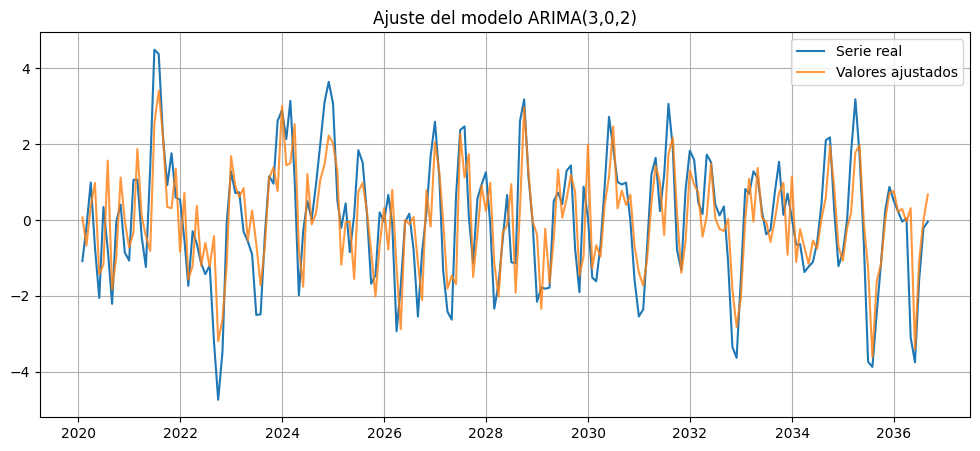

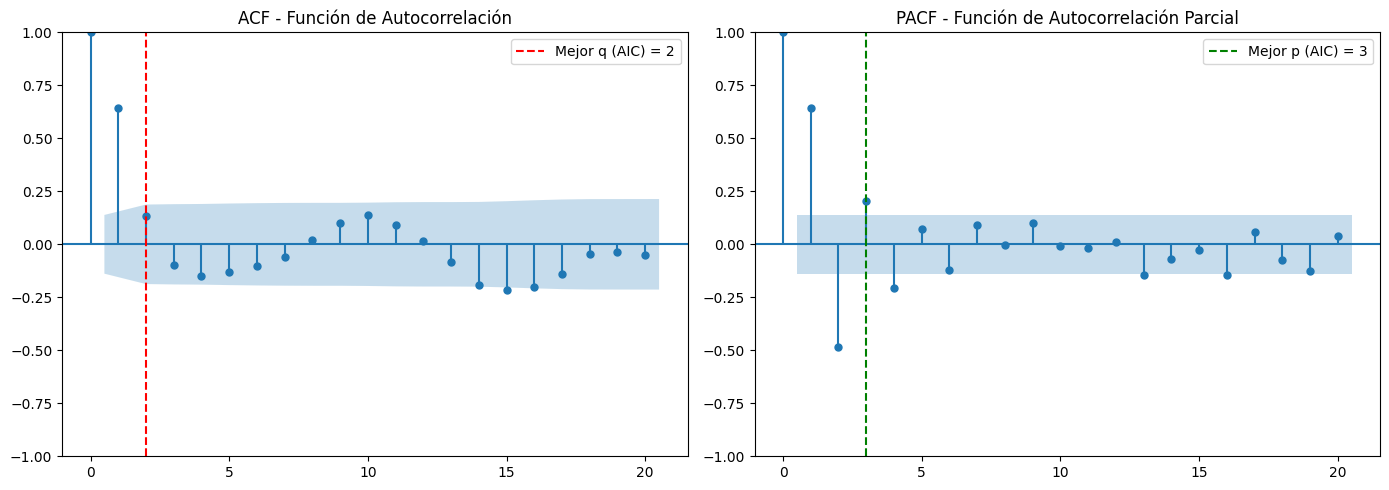

In [ ]:
# =========================================
# EJEMPLO ARIMA + AIC + BIC + ACF + PACF
# Listo para Google Colab
# =========================================

# Si hace falta instalar:
!pip install statsmodels --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# -----------------------------------------
# 1. Generar una serie de tiempo simulada
# -----------------------------------------
np.random.seed(123)

# Creamos una serie ARMA(2,1) y luego la tratamos con ARIMA
# AR: X_t = 0.6X_(t-1) -0.3X_(t-2) + error + ...
# MA: error_t + 0.5 error_(t-1)

ar = np.array([1, -0.6, 0.3])   # Ojo: statsmodels usa signos invertidos
ma = np.array([1, 0.5])

arma_process = ArmaProcess(ar, ma)
data = arma_process.generate_sample(nsample=200)

# Convertimos a serie con índice tipo tiempo
fechas = pd.date_range(start="2020-01-01", periods=200, freq="M")
serie = pd.Series(data, index=fechas)

print("Primeros datos de la serie:")
print(serie.head())

# -----------------------------------------
# 2. Graficar la serie
# -----------------------------------------
plt.figure(figsize=(12,5))
plt.plot(serie)
plt.title("Serie de tiempo simulada")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.grid(True)
plt.show()

# -----------------------------------------
# 3. Calcular y graficar ACF y PACF
# -----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14,5))

plot_acf(serie, lags=20, ax=axes[0])
axes[0].set_title("ACF - Función de Autocorrelación")

plot_pacf(serie, lags=20, ax=axes[1], method='ywm')
axes[1].set_title("PACF - Función de Autocorrelación Parcial")

plt.tight_layout()
plt.show()

# -----------------------------------------
# 4. Probar varios modelos ARIMA(p,d,q)
# -----------------------------------------
resultados = []

# Puedes cambiar rangos si quieres probar más modelos
for p_val in range(0, 4):
    for d_val in range(0, 2):
        for q_val in range(0, 4):
            try:
                modelo = ARIMA(serie, order=(p_val, d_val, q_val))
                ajuste = modelo.fit()
                resultados.append([p_val, d_val, q_val, ajuste.aic, ajuste.bic])
            except:
                continue

# Convertir resultados a DataFrame
tabla_resultados = pd.DataFrame(resultados, columns=["p", "d", "q", "AIC", "BIC"])

# Ordenar por AIC
tabla_aic = tabla_resultados.sort_values(by="AIC").reset_index(drop=True)

# Ordenar por BIC
tabla_bic = tabla_resultados.sort_values(by="BIC").reset_index(drop=True)

print("Top 10 modelos según AIC:")
print(tabla_aic.head(10))

print("\nTop 10 modelos según BIC:")
print(tabla_bic.head(10))

# -----------------------------------------
# 5. Elegir el mejor modelo
# -----------------------------------------
mejor_aic = tabla_aic.iloc[0]
mejor_bic = tabla_bic.iloc[0]

p_best_aic = int(mejor_aic['p'])
d_best_aic = int(mejor_aic['d'])
q_best_aic = int(mejor_aic['q'])

p_best_bic = int(mejor_bic['p'])
d_best_bic = int(mejor_bic['d'])
q_best_bic = int(mejor_bic['q'])

print("\nMejor modelo según AIC:")
print(f"ARIMA({p_best_aic},{d_best_aic},{q_best_aic}) con AIC = {mejor_aic['AIC']:.2f}")

print("\nMejor modelo según BIC:")
print(f"ARIMA({p_best_bic},{d_best_bic},{q_best_bic}) con BIC = {mejor_bic['BIC']:.2f}")

# -----------------------------------------
# 6. Ajustar el mejor modelo según AIC
# -----------------------------------------
p_best = p_best_aic
d_best = d_best_aic
q_best = q_best_aic

modelo_final = ARIMA(serie, order=(p_best, d_best, q_best))
ajuste_final = modelo_final.fit()

print("\nResumen del mejor modelo según AIC:")
print(ajuste_final.summary())

# -----------------------------------------
# 7. Graficar valores ajustados
# -----------------------------------------
plt.figure(figsize=(12,5))
plt.plot(serie, label="Serie real")
plt.plot(ajuste_final.fittedvalues, label="Valores ajustados", alpha=0.8)
plt.title(f"Ajuste del modelo ARIMA({p_best},{d_best},{q_best})")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------------------
# 8. Marcar p y q en las gráficas ACF y PACF
# -----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14,5))

plot_acf(serie, lags=20, ax=axes[0])
axes[0].set_title("ACF - Función de Autocorrelación")
# Marcar q_best en el gráfico ACF
axes[0].axvline(x=q_best, color='r', linestyle='--', label=f'Mejor q (AIC) = {q_best}')
axes[0].legend()

plot_pacf(serie, lags=20, ax=axes[1], method='ywm')
axes[1].set_title("PACF - Función de Autocorrelación Parcial")
# Marcar p_best en el gráfico PACF
axes[1].axvline(x=p_best, color='g', linestyle='--', label=f'Mejor p (AIC) = {p_best}')
axes[1].legend()

plt.tight_layout()
plt.show()


### Cómo se eligieron 'p' y 'q'

Los valores para `p` (orden del componente autorregresivo) y `q` (orden del componente de media móvil) se seleccionaron mediante un proceso de iteración sobre varios modelos ARIMA(p,d,q). Para cada combinación posible dentro de un rango predefinido, se ajustó un modelo ARIMA a la serie de tiempo. Luego, se calcularon el Criterio de Información de Akaike (AIC) y el Criterio de Información Bayesiano (BIC) para cada modelo.

El **AIC (Akaike Information Criterion)** y el **BIC (Bayesian Information Criterion)** son medidas que ayudan a seleccionar el modelo que mejor se ajusta a los datos, penalizando la complejidad del modelo (es decir, el número de parámetros). Generalmente, se prefiere el modelo con el valor de AIC o BIC más bajo.

En este caso, el modelo con el **AIC más bajo** resultó ser **ARIMA(3,0,2)**. Esto implica:

*   `p = 3`: Se utilizan 3 observaciones pasadas para el componente autorregresivo.
*   `d = 0`: No se aplicó diferenciación a la serie, lo que sugiere que la serie ya es estacionaria o que una diferenciación no mejoró significativamente el modelo.
*   `q = 2`: Se utilizan 2 errores de pronóstico pasados para el componente de media móvil.

Estos valores (`p=3` y `q=2`) son los que se marcaron en las gráficas de ACF y PACF.

### ¿Es este el 'mejor' modelo?

La elección del 'mejor' modelo en el análisis de series de tiempo, especialmente con criterios como AIC y BIC, es un aspecto importante a considerar.

En nuestro análisis, se utilizaron dos criterios principales para la selección del modelo:

*   **AIC (Akaike Information Criterion)**: Este criterio busca un equilibrio entre la bondad de ajuste del modelo y su complejidad (número de parámetros). Un valor de AIC más bajo generalmente indica un modelo preferible.

*   **BIC (Bayesian Information Criterion)**: Similar al AIC, pero el BIC penaliza la complejidad del modelo de manera más estricta, especialmente en conjuntos de datos grandes. Un valor de BIC más bajo también es deseable.

Según los resultados obtenidos:

*   El **mejor modelo según el AIC** fue `ARIMA(3,0,2)` con un valor de AIC de 592.22.
*   El **mejor modelo según el BIC** fue `ARIMA(0,0,2)` con un valor de BIC de 608.31.

Por lo tanto, el modelo `ARIMA(3,0,2)` se considera el 'mejor' bajo el criterio AIC, que es una práctica común. Sin embargo, si la prioridad fuera el criterio BIC, el modelo `ARIMA(0,0,2)` sería el elegido. La decisión entre usar AIC o BIC a menudo depende de los objetivos específicos del análisis y las características del dataset. En este cuaderno, el ajuste final se realizó utilizando el modelo con el AIC más bajo.

In [ ]:
# Display Top 10 models according to AIC
print("Top 10 modelos según AIC:")
display(tabla_aic.head(10))

Top 10 modelos según AIC:


,p,d,q,AIC,BIC
0,3,0,2,592.224623,615.312844
1,1,0,3,593.269137,613.059042
2,3,0,3,593.363692,619.750231
3,0,0,2,595.118136,608.311406
4,2,0,1,595.147518,611.639104
5,2,0,2,595.414408,615.204312
6,0,0,3,595.922088,612.413675
7,3,0,1,596.082146,615.872050
8,1,0,1,596.209139,609.402409
9,1,0,2,596.284747,612.776334


In [ ]:
# Display Top 10 models according to BIC
print("\nTop 10 modelos según BIC:")
display(tabla_bic.head(10))


Top 10 modelos según BIC:


,p,d,q,AIC,BIC
0,0,0,2,595.118136,608.311406
1,1,0,1,596.209139,609.402409
2,0,1,3,596.698990,609.872209
3,1,1,2,597.536070,610.709289
4,2,0,1,595.147518,611.639104
5,0,0,3,595.922088,612.413675
6,1,0,2,596.284747,612.776334
7,1,0,3,593.269137,613.059042
8,2,1,2,596.727186,613.193710
9,1,1,3,597.723260,614.189784


### Resumen del Análisis de Modelos ARIMA

Durante este análisis, hemos llevado a cabo los siguientes pasos clave:

1.  **Generación de Serie de Tiempo Simulada**: Creamos una serie de tiempo sintética para ilustrar el proceso de modelado ARIMA.

2.  **Visualización Inicial**: Graficamos la serie de tiempo para observar sus patrones iniciales.

3.  **Análisis de ACF y PACF**: Calculamos y visualizamos las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF). Estas gráficas son fundamentales para la identificación de los órdenes `p` y `q` iniciales del modelo ARIMA.

4.  **Selección de Modelos ARIMA**: Iteramos sobre un rango de posibles órdenes `(p, d, q)` y ajustamos múltiples modelos ARIMA. Para cada modelo, calculamos el Criterio de Información de Akaike (AIC) y el Criterio de Información Bayesiano (BIC).

    *   El **mejor modelo según AIC** fue **ARIMA(3,0,2)** con un AIC de 592.22.
    *   El **mejor modelo según BIC** fue **ARIMA(0,0,2)** con un BIC de 608.31.

5.  **Ajuste del Modelo Final**: Basándonos en el criterio de AIC, el modelo **ARIMA(3,0,2)** fue seleccionado y ajustado a la serie de tiempo, y se mostró su resumen estadístico.

6.  **Visualización de Ajuste**: Graficamos los valores ajustados del modelo ARIMA(3,0,2) contra la serie real para evaluar visualmente el rendimiento del ajuste.

7.  **Marcado de p y q en Gráficas**: Los valores óptimos de `p` (3) y `q` (2) se marcaron en las gráficas de PACF y ACF, respectivamente, para una referencia visual clara.

8.  **Discusión sobre la Elección del 'Mejor' Modelo**: Se explicó que el concepto de 'mejor' modelo depende del criterio de selección (AIC vs. BIC) y que el modelo final se basó en el AIC.

9.  **Principio de Parsimonia**: Se describió cómo el Principio de Parsimonia, a través de AIC y BIC, guía la selección de un modelo que equilibre la bondad del ajuste con la simplicidad del modelo.

### Análisis de Residuales del Mejor Modelo (ARIMA(3,0,2))

Los residuales son la diferencia entre los valores observados y los valores predichos por el modelo. Un buen modelo debe tener residuales que se parezcan a 'ruido blanco', es decir, que sean independientes, identicamente distribuidos y con una media cercana a cero. Analicemos los residuales de nuestro modelo ARIMA(3,0,2).

Estadísticas descriptivas de los residuales:
count    200.000000
mean       0.007309
std        1.029063
min       -3.405868
25%       -0.715597
50%        0.022401
75%        0.702382
max        2.325912
dtype: float64


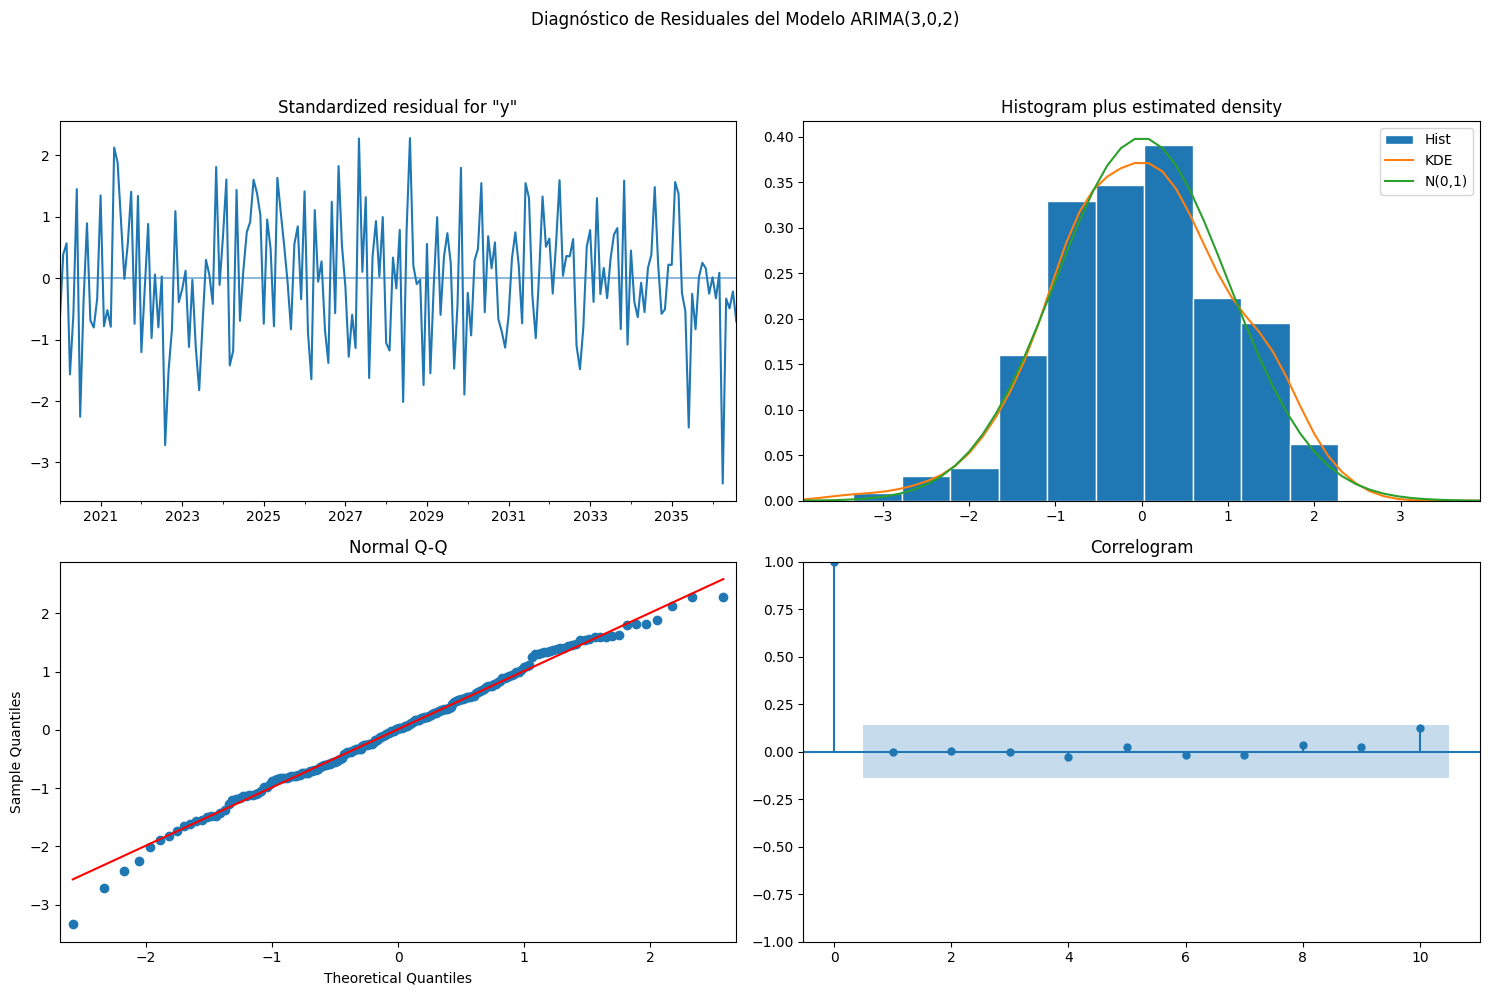

In [ ]:
# Obtener los residuales del modelo ajustado
residuals = ajuste_final.resid

print("Estadísticas descriptivas de los residuales:")
print(residuals.describe())

# Plot de diagnósticos de los residuales
# Esto incluye:
# 1. Residuales estandarizados a lo largo del tiempo
# 2. Histograma de los residuales con estimación de densidad (KDE)
# 3. Q-Q plot para verificar la normalidad
# 4. Correlograma (ACF) de los residuales para verificar autocorrelación

fig = ajuste_final.plot_diagnostics(figsize=(15, 10))
plt.suptitle('Diagnóstico de Residuales del Modelo ARIMA(3,0,2)', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


#### Interpretación de los Gráficos de Diagnóstico:

*   **Residuales Estandarizados**: Deberían oscilar alrededor de cero sin patrones claros o variabilidad creciente/decreciente. Picos grandes pueden indicar valores atípicos.
*   **Histograma y KDE**: Deberían parecerse a una distribución normal, centrada en cero.
*   **Q-Q Plot Normal**: Los puntos deberían seguir de cerca la línea recta de 45 grados, indicando normalidad.
*   **Correlograma (ACF) de Residuales**: Ninguna de las barras de autocorrelación debería exceder significativamente las bandas de confianza azules, lo que sugeriría que no hay autocorrelación restante en los residuales (es decir, son ruido blanco).

### Resumen de los Modelos y Residuales en DataFrame

In [ ]:
# DataFrame con los mejores modelos según AIC y BIC
resumen_modelos = pd.DataFrame({
    'Criterio': ['AIC', 'BIC'],
    'p': [p_best_aic, p_best_bic],
    'd': [d_best_aic, d_best_bic],
    'q': [q_best_aic, q_best_bic],
    'Valor_Criterio': [mejor_aic['AIC'], mejor_bic['BIC']]
})

print("Resumen de los Modelos Óptimos:")
display(resumen_modelos)

print("\nEstadísticas Descriptivas de los Residuales:")
display(residuals.describe().to_frame().T)


Resumen de los Modelos Óptimos:


,Criterio,p,d,q,Valor_Criterio
0,AIC,3,0,2,592.224623
1,BIC,0,0,2,608.311406



Estadísticas Descriptivas de los Residuales:


,count,mean,std,min,25%,50%,75%,max
0,200.0,0.007309,1.029063,-3.405868,-0.715597,0.022401,0.702382,2.325912


### 9. Generar un Pronóstico (Forecast)

Vamos a generar un pronóstico a partir de nuestro mejor modelo ajustado, `ARIMA(3,0,2)`. El pronóstico incluirá un intervalo de confianza para darnos una idea de la incertidumbre de las predicciones.

In [ ]:
# Definir el número de pasos a pronosticar (por ejemplo, 12 meses)
num_forecast_steps = 12

# Generar el pronóstico
forecast_result = ajuste_final.get_forecast(steps=num_forecast_steps)

# Obtener los valores predichos y los intervalos de confianza
forecast_values = forecast_result.predicted_mean
confidence_intervals = forecast_result.conf_int(alpha=0.05) # Intervalo de confianza del 95%

print("Pronóstico para los próximos 12 periodos:")
print(forecast_values)

print("\nIntervalos de confianza del 95% para el pronóstico:")
print(confidence_intervals)

Pronóstico para los próximos 12 periodos:
2036-09-30    0.293384
2036-10-31    0.923670
2036-11-30    1.133128
2036-12-31    1.105727
2037-01-31    1.004657
2037-02-28    0.895968
2037-03-31    0.797338
2037-04-30    0.710777
2037-05-31    0.634903
2037-06-30    0.568174
2037-07-31    0.509360
2037-08-31    0.457479
Freq: ME, Name: predicted_mean, dtype: float64

Intervalos de confianza del 95% para el pronóstico:
             lower y   upper y
2036-09-30 -1.703927  2.290695
2036-10-31 -2.054334  3.901674
2036-11-30 -1.904368  4.170624
2036-12-31 -1.939435  4.150890
2037-01-31 -2.073310  4.082624
2037-02-28 -2.215788  4.007723
2037-03-31 -2.341425  3.936102
2037-04-30 -2.448608  3.870161
2037-05-31 -2.540261  3.810067
2037-06-30 -2.619156  3.755504
2037-07-31 -2.687393  3.706114
2037-08-31 -2.746590  3.661547


### 10. Visualizar el Pronóstico

Para entender mejor el pronóstico, lo graficaremos junto con la serie original y sus intervalos de confianza.

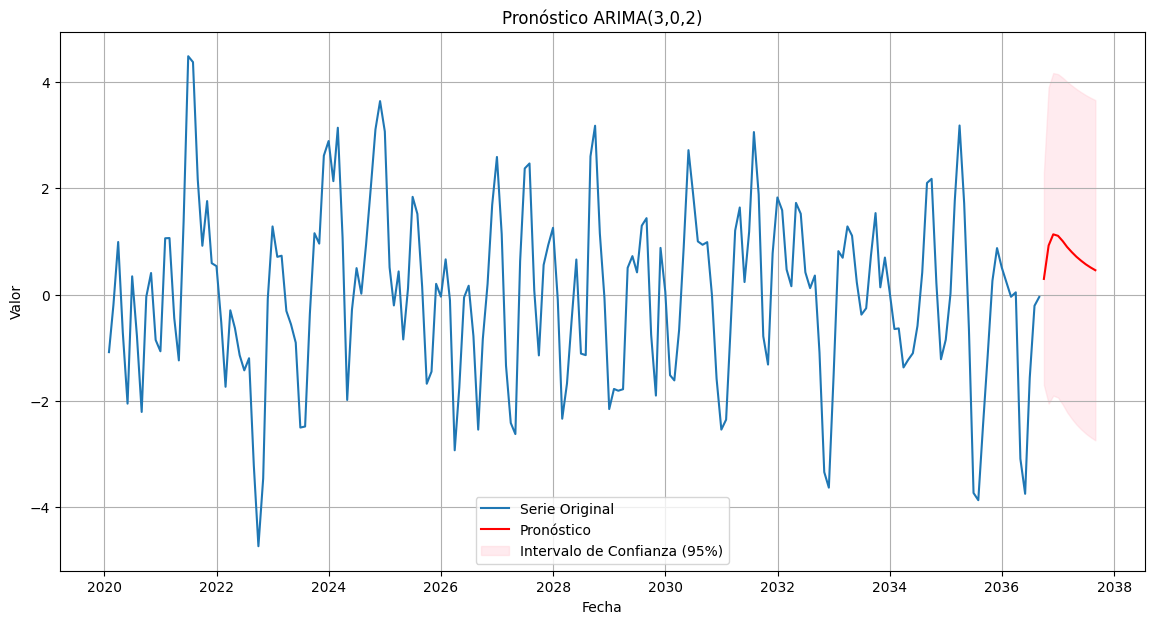

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(serie, label='Serie Original')

# Plot the forecast
plt.plot(forecast_values.index, forecast_values, color='red', label='Pronóstico')

# Plot confidence intervals
plt.fill_between(confidence_intervals.index,
                 confidence_intervals.iloc[:, 0],
                 confidence_intervals.iloc[:, 1],
                 color='pink', alpha=0.3, label='Intervalo de Confianza (95%)')

plt.title(f'Pronóstico ARIMA({p_best},{d_best},{q_best})')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()

### Análisis de Series de Tiempo con Meta Prophet (Datos de URL)

Ahora, vamos a realizar un análisis similar pero utilizando la librería `Prophet` de Meta (anteriormente Facebook Prophet) y un conjunto de datos real tomado de una URL. `Prophet` es una herramienta robusta para pronosticar series de tiempo, especialmente aquellas con fuertes efectos estacionales.

In [ ]:
# 1. Instalar la librería Prophet
# Si no está instalada, se debe ejecutar:
!pip install prophet --quiet

import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

print("Librerías instaladas e importadas correctamente.")

Librerías instaladas e importadas correctamente.


### 2. Cargar Datos desde una URL y Preprocesar para Prophet

Utilizaremos un conjunto de datos público de temperaturas mínimas diarias en Melbourne, Australia. Prophet requiere que las columnas de la serie de tiempo se llamen `ds` (para la fecha/hora) e `y` (para el valor a pronosticar).

In [ ]:
# URL del dataset de temperaturas mínimas diarias
data_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'

# Cargar los datos
df_prophet = pd.read_csv(data_url, header=0)

# Renombrar columnas a 'ds' y 'y' y convertir 'ds' a formato datetime
df_prophet.columns = ['ds', 'y']
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

print("Primeros 5 datos del dataset preparado para Prophet:")
print(df_prophet.head())
print("\nÚltimos 5 datos del dataset:")
print(df_prophet.tail())
print("\nInformación del DataFrame:")
df_prophet.info()

Primeros 5 datos del dataset preparado para Prophet:
          ds     y
0 1981-01-01  20.7
1 1981-01-02  17.9
2 1981-01-03  18.8
3 1981-01-04  14.6
4 1981-01-05  15.8

Últimos 5 datos del dataset:
             ds     y
3645 1990-12-27  14.0
3646 1990-12-28  13.6
3647 1990-12-29  13.5
3648 1990-12-30  15.7
3649 1990-12-31  13.0

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      3650 non-null   datetime64[ns]
 1   y       3650 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 57.2 KB


### 3. Visualizar la Serie de Tiempo Original

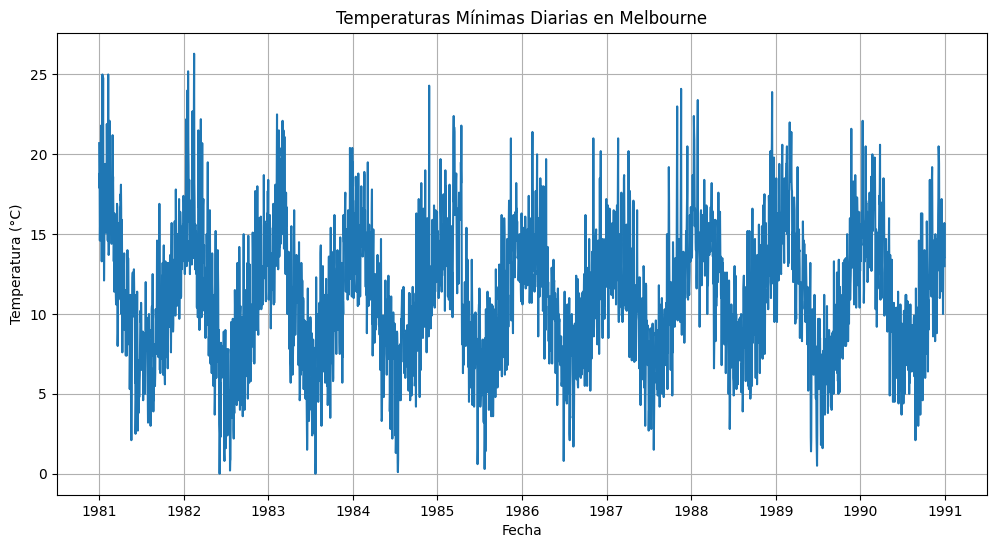

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_prophet['ds'], df_prophet['y'])
plt.title('Temperaturas Mínimas Diarias en Melbourne')
plt.xlabel('Fecha')
plt.ylabel('Temperatura (°C)')
plt.grid(True)
plt.show()

### 4. Entrenar el Modelo Prophet y Generar Pronóstico

Prophet detecta automáticamente la estacionalidad diaria, semanal y anual. Podemos configurarlo con parámetros adicionales si conocemos patrones específicos.

In [ ]:
# Inicializar el modelo Prophet
# Podemos añadir estacionalidades si es necesario, por ejemplo: yearly_seasonality=True, weekly_seasonality=True
model = Prophet(yearly_seasonality=True)

# Entrenar el modelo
model.fit(df_prophet)

# Crear un DataFrame con fechas futuras para el pronóstico (ej. los próximos 365 días)
future = model.make_future_dataframe(periods=365)

print("Primeros 5 datos de las fechas futuras para el pronóstico:")
print(future.head())
print("\nÚltimos 5 datos de las fechas futuras para el pronóstico:")
print(future.tail())

# Realizar el pronóstico
forecast = model.predict(future)

print("\nPrimeros 5 datos del pronóstico (con componentes):")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())
print("\nÚltimos 5 datos del pronóstico:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Primeros 5 datos de las fechas futuras para el pronóstico:
          ds
0 1981-01-01
1 1981-01-02
2 1981-01-03
3 1981-01-04
4 1981-01-05

Últimos 5 datos de las fechas futuras para el pronóstico:
             ds
4010 1991-12-27
4011 1991-12-28
4012 1991-12-29
4013 1991-12-30
4014 1991-12-31

Primeros 5 datos del pronóstico (con componentes):
          ds       yhat  yhat_lower  yhat_upper
0 1981-01-01  15.173804   11.609574   18.593106
1 1981-01-02  15.218944   11.922414   18.988405
2 1981-01-03  15.254090   11.875324   18.528422
3 1981-01-04  15.234878   11.934471   18.598319
4 1981-01-05  15.439042   11.925812   19.030485

Últimos 5 datos del pronóstico:
             ds       yhat  yhat_lower  yhat_upper
4010 1991-12-27  14.527469   11.059619   17.806425
4011 1991-12-28  14.546085   10.920932   17.994200
4012 1991-12-29  14.517556   11.306459   18.062052
4013 1991-12-30  14.720087   11.347464   18.286285
4014 1991-12-31  14.891291   11.532866   18.261933


### 5. Visualizar el Pronóstico de Prophet

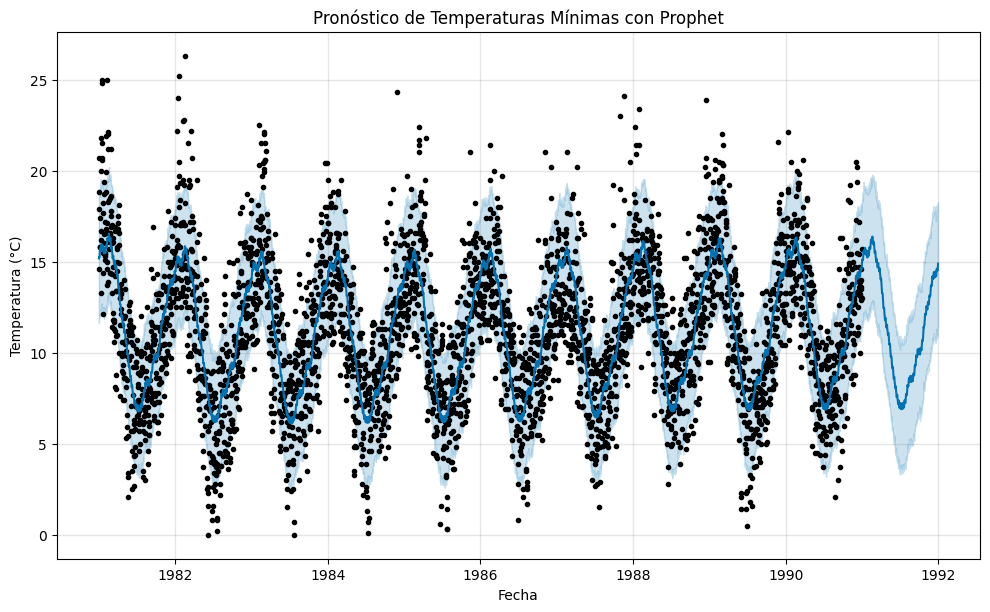

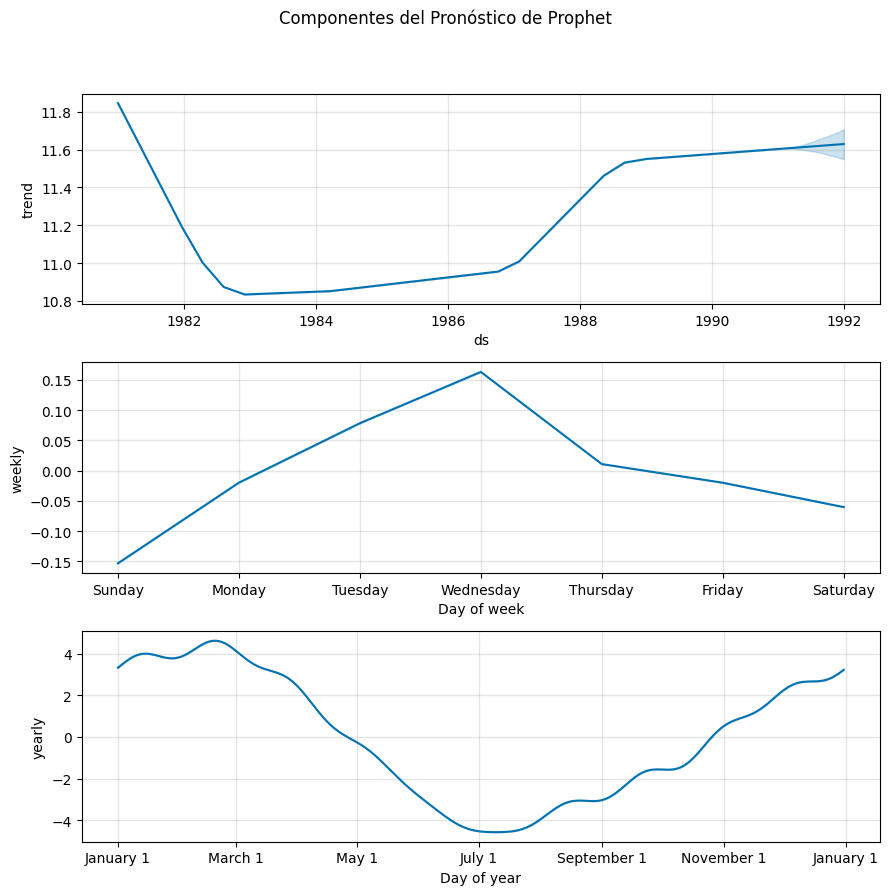

In [ ]:
fig1 = model.plot(forecast)
plt.title('Pronóstico de Temperaturas Mínimas con Prophet')
plt.xlabel('Fecha')
plt.ylabel('Temperatura (°C)')
plt.grid(True)
plt.show()

# También podemos visualizar los componentes del pronóstico (tendencia, estacionalidad anual, etc.)
fig2 = model.plot_components(forecast)
plt.suptitle('Componentes del Pronóstico de Prophet', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Principio de Parsimonia en la Selección del Modelo

El principio de parsimonia, a menudo conocido como la Navaja de Occam, sugiere que entre varias explicaciones o modelos que ajustan los datos igualmente bien, la explicación o modelo más simple es preferible. En el contexto de la modelización estadística, esto se traduce en preferir modelos con menos parámetros, siempre que no sacrifiquen significativamente la bondad del ajuste.

En la selección de modelos ARIMA, el **Criterio de Información de Akaike (AIC)** y el **Criterio de Información Bayesiano (BIC)** son dos herramientas clave que incorporan este principio:

*   **Penalización por Complejidad**: Tanto el AIC como el BIC no solo consideran qué tan bien el modelo se ajusta a los datos (verosimilitud o log-likelihood), sino que también aplican una penalización por la cantidad de parámetros que utiliza el modelo. Esta penalización disuade la selección de modelos excesivamente complejos que podrían "sobreajustar" los datos, capturando ruido en lugar de patrones reales.

    *   **AIC**: Su fórmula es `AIC = 2k - 2ln(L)`, donde `k` es el número de parámetros del modelo y `L` es la máxima verosimilitud. El término `2k` representa la penalización por la complejidad.
    *   **BIC**: Su fórmula es `BIC = k ln(n) - 2ln(L)`, donde `n` es el número de observaciones. El BIC impone una penalización más fuerte por la complejidad (`k ln(n)` vs `2k` del AIC), especialmente en conjuntos de datos grandes. Esto a menudo lleva al BIC a seleccionar modelos más simples que el AIC.

Al elegir el modelo con el valor más bajo de AIC o BIC, estamos buscando un equilibrio óptimo entre la capacidad del modelo para explicar los datos y su simplicidad, adhiriéndonos así al principio de parsimonia.

Modelo SARIMA

### 11. Introducción al Modelo SARIMA

Los modelos **SARIMA (Seasonal AutoRegressive Integrated Moving Average)** son una extensión de los modelos ARIMA que permiten modelar series de tiempo que exhiben patrones estacionales. Estos modelos se especifican con dos conjuntos de órdenes:

*   **Orden no estacional: `(p, d, q)`**
    *   `p`: Orden del componente autorregresivo (AR) no estacional.
    *   `d`: Orden de diferenciación (Integrated) no estacional.
    *   `q`: Orden del componente de media móvil (MA) no estacional.

*   **Orden estacional: `(P, D, Q, S)`**
    *   `P`: Orden del componente autorregresivo (AR) estacional.
    *   `D`: Orden de diferenciación (Integrated) estacional.
    *   `Q`: Orden del componente de media móvil (MA) estacional.
    *   `S`: Longitud de la temporada (por ejemplo, 12 para datos mensuales con estacionalidad anual, 4 para datos trimestrales, 7 para datos diarios con estacionalidad semanal).

El usuario ha solicitado el **SARIMA(0,1,1)(0,1,1)12**, conocido como el 'modelo de la aerolínea', que es muy efectivo para series con patrones estacionales y tendencia.

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA

# 12. Ajustar el Modelo SARIMA(0,1,1)(0,1,1)12 (Airline Model)

# Re-crear la serie 'serie' y sus dependencias para asegurar la ejecución independiente de esta celda
# (Esto se hace para solucionar el 'NameError: name 'serie' is not defined' si la celda inicial no se ejecutó)
np.random.seed(123)
ar = np.array([1, -0.6, 0.3])
ma = np.array([1, 0.5])
arma_process = ArmaProcess(ar, ma)
data = arma_process.generate_sample(nsample=200)
fechas = pd.date_range(start="2020-01-01", periods=200, freq="M")
serie = pd.Series(data, index=fechas)

# Definir el orden no estacional
order_non_seasonal = (0, 1, 1)

# Definir el orden estacional y la longitud de la temporada
# S=12 para estacionalidad anual en datos mensuales
seasonal_order = (0, 1, 1, 12)

print(f"Ajustando modelo SARIMA{order_non_seasonal}{seasonal_order}...")

# Ajustar el modelo SARIMA
# La serie simulada original 'serie' es mensual, por lo que S=12 es apropiado para estacionalidad anual.
modelo_sarima = ARIMA(serie, order=order_non_seasonal, seasonal_order=seasonal_order)
ajuste_sarima = modelo_sarima.fit()

print("\nResumen del Modelo SARIMA(0,1,1)(0,1,1)12:")
print(ajuste_sarima.summary())

/tmp/ipykernel_1321/4122309877.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  fechas = pd.date_range(start="2020-01-01", periods=200, freq="M")


Ajustando modelo SARIMA(0, 1, 1)(0, 1, 1, 12)...

Resumen del Modelo SARIMA(0,1,1)(0,1,1)12:
                                    SARIMAX Results                                     
Dep. Variable:                                y   No. Observations:                  200
Model:             ARIMA(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -325.513
Date:                          Thu, 26 Mar 2026   AIC                            657.026
Time:                                  01:37:42   BIC                            666.719
Sample:                              01-31-2020   HQIC                           660.953
                                   - 08-31-2036                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.7175      0.056     

### 13. Generar Pronósticos con el Modelo SARIMA

Ahora, generaremos pronósticos para los próximos períodos utilizando el modelo SARIMA ajustado. Utilizaremos el mismo número de pasos de pronóstico que en el ejemplo ARIMA previo, por ejemplo, 12 meses.

In [ ]:
# Definir el número de pasos a pronosticar (ej. 12 meses)
num_forecast_steps_sarima = 12

# Generar el pronóstico
forecast_result_sarima = ajuste_sarima.get_forecast(steps=num_forecast_steps_sarima)

# Obtener los valores predichos y los intervalos de confianza
forecast_values_sarima = forecast_result_sarima.predicted_mean
confidence_intervals_sarima = forecast_result_sarima.conf_int(alpha=0.05) # Intervalo de confianza del 95%

print("Pronóstico SARIMA para los próximos 12 periodos:")
print(forecast_values_sarima)

print("\nIntervalos de confianza del 95% para el pronóstico SARIMA:")
print(confidence_intervals_sarima)

Pronóstico SARIMA para los próximos 12 periodos:
2036-09-30   -0.412347
2036-10-31   -0.753460
2036-11-30   -0.338567
2036-12-31   -0.305101
2037-01-31   -0.428620
2037-02-28   -0.547203
2037-03-31   -0.455818
2037-04-30   -0.753427
2037-05-31   -0.680698
2037-06-30   -0.599189
2037-07-31   -0.380165
2037-08-31   -0.202136
Freq: ME, Name: predicted_mean, dtype: float64

Intervalos de confianza del 95% para el pronóstico SARIMA:
              lower y    upper y
2036-09-30  -2.982220   2.157526
2036-10-31  -5.860856   4.353936
2036-11-30  -7.088881   6.411747
2036-12-31  -8.370334   7.760132
2037-01-31  -9.622395   8.765155
2037-02-28 -10.744334   9.649929
2037-03-31 -11.566061  10.654425
2037-04-30 -12.707234  11.200380
2037-05-31 -13.422342  12.060947
2037-06-30 -14.082716  12.884339
2037-07-31 -14.566832  13.806501
2037-08-31 -15.058700  14.654429


### 14. Visualizar el Pronóstico SARIMA

Graficaremos la serie original, los valores ajustados por el modelo SARIMA y los pronósticos con sus intervalos de confianza.

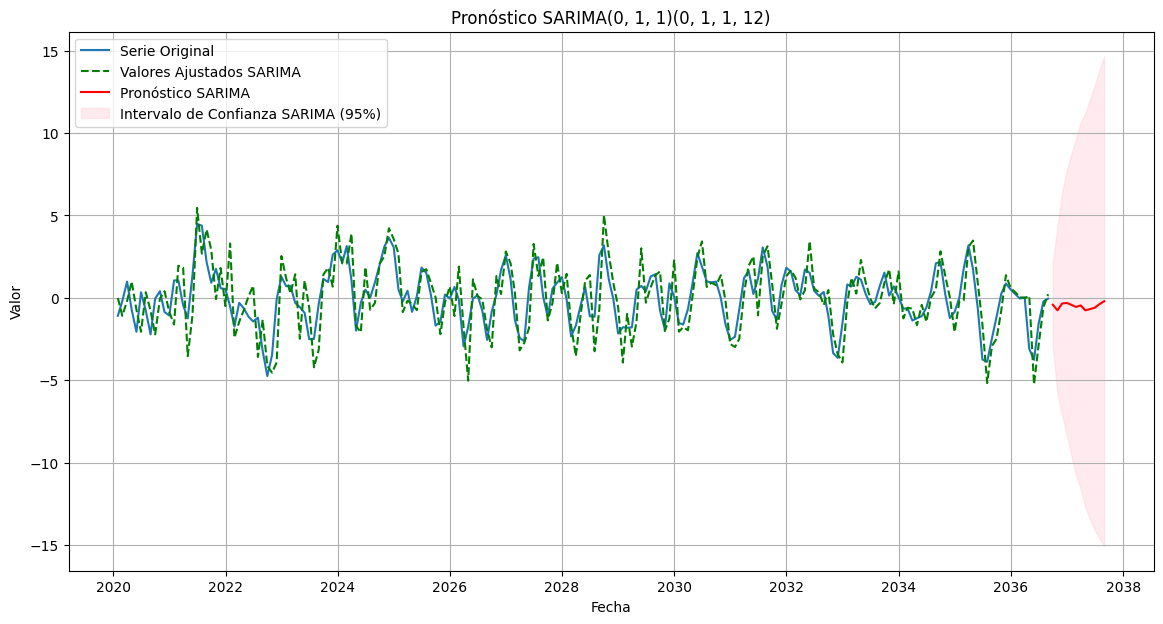

In [ ]:
import matplotlib.pyplot as plt # Added import for plt

plt.figure(figsize=(14, 7))
plt.plot(serie, label='Serie Original')
plt.plot(ajuste_sarima.fittedvalues, color='green', linestyle='--', label='Valores Ajustados SARIMA')

# Plot the SARIMA forecast
plt.plot(forecast_values_sarima.index, forecast_values_sarima, color='red', label='Pronóstico SARIMA')

# Plot confidence intervals for SARIMA forecast
plt.fill_between(confidence_intervals_sarima.index,
                 confidence_intervals_sarima.iloc[:, 0],
                 confidence_intervals_sarima.iloc[:, 1],
                 color='pink', alpha=0.3, label='Intervalo de Confianza SARIMA (95%)')

plt.title(f'Pronóstico SARIMA{order_non_seasonal}{seasonal_order}')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()

### 15. ¿Usamos Box-Jenkins?

Sí, la metodología utilizada para construir y ajustar los modelos ARIMA y SARIMA en este cuaderno se alinea directamente con la **metodología de Box-Jenkins**.

La metodología Box-Jenkins consta de un proceso iterativo de cuatro pasos:

1.  **Identificación**: Usando gráficas ACF y PACF para identificar los órdenes `p`, `d`, `q`, `P`, `D`, `Q` y `S` del modelo. Aunque en este caso el usuario ha especificado el modelo SARIMA directamente, la identificación inicial para el modelo ARIMA `(p,d,q)` se realizó visualizando ACF/PACF y evaluando AIC/BIC.
2.  **Estimación**: Estimar los coeficientes del modelo seleccionado utilizando métodos de máxima verosimilitud (MLE), que es lo que hace `statsmodels.tsa.arima.model.ARIMA.fit()`.
3.  **Diagnóstico**: Evaluar la adecuación del modelo ajustado, examinando los residuales (por ejemplo, verificando si se comportan como ruido blanco a través de su ACF/PACF, y pruebas de normalidad/homocedasticidad). La función `plot_diagnostics()` que utilizamos previamente es una herramienta clave en esta etapa.
4.  **Pronóstico**: Una vez que el modelo ha sido validado, se utiliza para generar predicciones futuras.

El `statsmodels` paquete de Python implementa este enfoque de manera robusta, permitiendo el ajuste de modelos que siguen esta estructura y metodología.